<table style="width:100%; border-bottom: 2px solid #ccc; margin-bottom: 20px;">
  <tr>
    <td style="vertical-align:middle;">
      <img src="../../resources/ADI-Logo-RGB-FullColor.png" alt="Company Logo" height="30">
    </td>
    <td style="text-align:right; vertical-align:middle;">
      <p style="margin: 0;">Phased Array Systems</p>
      <p style="font-size: 14px; margin: 0;">Iain Derrington – ADEF Group, ADI</p>
      <p style="font-size: 12px; color: #555;">Field Applications & Platform Engineer</p>
    </td>
  </tr>
</table>

# Measuring Direction of Arrival (DoA)

In the preceding notebooks, we've developed an understanding of beamforming fundamentals, explored how the Phaser hardware operates, and run calibration routines to remove phase and gain mismatches between elements.

In this workshop, the Phaser is a receive-only system. We will use it to estimate the **Direction of Arrival (DoA)** of a reference continuous-wave signal near **10 GHz**.

We will use a simple brute-force method known as **beam scanning** or **Bartlett beamforming**. This involves:

- Set the beamforming direction to a specific angle, by applying the corresponding phase shifts to the array.
- Measuring the received signal using the SDR
- Performing an FFT to extract signal magnitude
- Repeating this across a range of scan angles

The result is a **spatial power spectrum**, where the peak indicates the angle from which the signal is arriving.

This method is intuitive and easy to implement, though not as precise as more advanced techniques like MUSIC or ESPRIT.

---

The first part of this application, simply configures the Phaser for operation.

- Rx Only
- 10.5 GHz Operation (Ish))
- 2.2 GHz IF
- Aprz 20MHz iBW
- Gain and Phase calibration coefficents loaded and used behind the scenes


In [2]:
%matplotlib inline
print("Running...\n")

import sys
sys.path.insert(0, '../src')

import os
import time
from time import sleep
import matplotlib.pyplot as plt

from IPython.display import display, update_display, Markdown
import git
from pathlib import Path
import numpy as np
from adi import ad9361
from adi.cn0566 import CN0566
from scipy import signal
import config_custom as config
from phaser_functions import (calculate_plot, 
                                channel_calibration, 
                                gain_calibration, 
                                load_hb100_cal,
                                phase_calibration)
from phaser_init import init_phaser_sdr

plt.style.use('ggplot')
np.set_printoptions(legacy='1.25', precision=2)

phaser_root = get_phaser_root()
resource_path = phaser_root / "resources"

print(f"Resource path: {resource_path}")

try:
    print(f"Attempting to connect to R_Pi via ip:{config.RASP_IP_ADDRS}...")
    my_phaser = CN0566(uri="ip:" + config.RASP_IP_ADDRS)
    print(f"CN0566 Connected.")
    
except:
    print("Unable to connect to Phaser. Make sure it is connected and powered on.")
    sys.exit(1)

try:
    print(f"Attempting to connect to Pluto via ip:{config.PLUTO_IP_ADDRS}...")
    my_sdr = ad9361(uri="ip:" + config.PLUTO_IP_ADDRS)
    print(f"PlutoSDR connected.\n")
except:
    print("Unable to connect to Pluto. Make sure it is connected and powered on.")
    sys.exit(1)
    
my_phaser.sdr = my_sdr  # Set my_phaser.sdr

"""
 Initialise Pluto
"""
print(f"Initialise Pluto")
# By default device_mode is "rx"
my_phaser.configure(device_mode="rx")
init_phaser_sdr(my_phaser, 30000000, config.rx_freq, rx_gain=6, tx_gain=-6, buffer_size=1024)

print(f"Converter Sample Rate = {30000000/1e6} Msps")
print(f"Tx frequency = {config.tx_freq/1e9} GHz (Not used)")
print(f"Rx frequency = {config.tx_freq/1e9} GHz (Not used)")
print(f"Tx Gain = -6")
print(f"Rx Gain =  6")
print(f"Buffer size = 1024 bytes \n")

# Load the gain calibration for pluto. Corrects for Rx 0 / 1 differences
my_phaser.load_channel_cal(filename=resource_path / "channel_cal_val.pkl")

# Apply gain calibration
print(f"Apply channel calibration")
my_phaser.sdr.rx_hardwaregain_chan0 = (my_phaser.sdr.rx_hardwaregain_chan0 + my_phaser.ccal[0])
my_phaser.sdr.rx_hardwaregain_chan1 = (my_phaser.sdr.rx_hardwaregain_chan1 + my_phaser.ccal[1])

print(f"Rx Chan 0 Cal = {my_phaser.ccal[0]}")
print(f"Rx Chan 1 Cal = {my_phaser.ccal[1]}")

"""
Set up receive frequency. When using HB100, you need to know its frequency
fairly accurately. Use the cn0566_find_hb100.py script to measure its frequency
and write out to the cal file. IF using the onboard TX generator, delete
the cal file and set frequency via config.py or config_custom.py.
"""
try:
    my_phaser.signalFreq = load_hb100_cal(filename=resource_path / "hb100_freq_val.pkl")
    print(f"Found signal freq file f = {my_phaser.signalFreq} Hz ",)
except:
    my_phaser.signalFreq = config.signalFreq
    print(f"No signal freq found, keeping at {my_phaser.signalFreq} ")


#  Configure SDR parameters.
my_sdr.filter = resource_path / "LTE20_MHz.ftr"  # Load LTE 20 MHz filter

# To disable tx, set attenuation to a high value and set frequency far from rx.
my_sdr.tx_hardwaregain_chan0 = int(-88)  # this is a negative number between 0 and -88
my_sdr.tx_hardwaregain_chan1 = int(-88)
my_sdr.tx_lo = int(1.0e9)


"""
Configure PLL
"""
my_phaser.frequency = (int(my_phaser.signalFreq) + config.rx_freq ) // 4  # PLL feedback via /4 VCO output
my_phaser.freq_dev_step = 5690
my_phaser.freq_dev_range = 0
my_phaser.freq_dev_time = 0
my_phaser.powerdown = 0
my_phaser.ramp_mode = "disabled"

print(f"PLL fixed frequency = {my_phaser.frequency}/1e9 GHz")

"""
If you want to use previously calibrated values load_gain and load_phase values by passing path of previously
stored values. If this is not done system will be working as uncalibrated system.
These will fail gracefully and default to no calibration if files not present.
"""

my_phaser.load_gain_cal(filename= resource_path / "gain_cal_val.pkl")
my_phaser.load_phase_cal(filename= resource_path / "phase_cal_val.pkl")

print(f"Gain Cal = {my_phaser.gcal}")
print(f"Phase Cal = {my_phaser.pcal}")

"""
 To set gain of all channels with different values.
     Here's where you would apply a window / taper function,
     but we're starting with rectangular / SINC1.
"""
gain_list = [127, 127, 127, 127, 127, 127, 127, 127]
for i in range(0, len(gain_list)):
    my_phaser.set_chan_gain(i, gain_list[i], apply_cal=True)

# Averages decide number of time samples are taken to plot and/or calibrate system. By default it is 1.
my_phaser.Averages = 1

# Aim the beam at boresight by default
my_phaser.set_beam_phase_diff(0.0)

print(f"\nComplete")

Running...



RuntimeError: Could not locate 'phaser' folder from path: C:\ADI Repo\PhaserTes\beam-forming-tutorials
Make sure you're running from within the 'phaser' project hierarchy.If running in VSCode attach to .venv and not ipykernal.

The following code performs the beam sweep. The bulk of the calculations are done within calculate_plot() which is appended shown in the following cell.

In [6]:
def Calculate_Steering_Angle(phase_delta, cn0566):
    # Calculate the beam steering angle
    if phase_delta >= 0:
        steerAngle = np.degrees(
            np.arcsin(
                max(
                    min(
                        1,
                        (cn0566.c * np.radians(np.abs(phase_delta)))
                        / (2 * np.pi * cn0566.signalFreq * cn0566.element_spacing),
                    ),
                    -1,
                )
            )
        )
              # positive PhaseDelta covers 0deg to 90 deg
    else:
        steerAngle = -(
            np.degrees(
                np.arcsin(
                    max(
                            min(
                                1,
                                (cn0566.c * np.radians(np.abs(phase_delta)))
                                / (
                                    2
                                    * np.pi
                                    * cn0566.signalFreq
                                    * cn0566.element_spacing
                                ),
                            ),
                            -1,
                        )
                    )
                )
            )  # negative phase delta covers 0 deg to -90 deg
    
    return steerAngle

def calculate_plot(cn0566, gcal_element=0, cal_element=0):
    """ Calculate all the values required to do different antenna pattern plots.
        parameters:
            cn0566: Handle to CN0566 instance
        returns:
            gain: Antenna gain data
            angle: Antenna angles (calculated from phases sent to array)
            delta: Delta between sub-arrays (for monopulse tracking)
            diff_error:
            xf:
            max_gain:
            phaseValues: Actual phase values sent to array
    """
    sweep_angle = 180  # This sweeps the beam angle from -70 deg to +70
    
    # These are all the phase deltas (i.e. phase difference between Rx1 and Rx2, then Rx2 and Rx3, etc.) we'll sweep
    phaseValues = np.arange( -(sweep_angle), (sweep_angle), cn0566.phase_step_size)
    
    gain, delta, angle = (
        [],
        [],
        [],
    )  # Create empty lists
    
    numSamples = cn0566.sdr.rx_buffer_size
    win = np.blackman(numSamples)
    win /= np.average(win)
    
    for phase in phaseValues:  
        # set Phase of channels based on Calibration Flag status and calibration element
        cn0566.set_beam_phase_diff(phase)
         
        # initialise totals 
        total_sum, total_delta = 0, 0
        
        for count in range(0, cn0566.Averages):  # repeat loop and average the results
            
            # read a buffer of data from Pluto using pyadi-iio library (adi.py)
            data = (cn0566.sdr.rx())  
            
            # calculate the sum a difference
            data_fft = data[0] + data[1]
            y_sum = data_fft * win
            y_delta = (data[0] - data[1]) * win
            
            # take FFT of sum and difference (ingnore phase)
            s_sum = np.fft.fftshift(np.absolute(np.fft.fft(y_sum)))
            s_delta = np.fft.fftshift(np.absolute(np.fft.fft(y_delta)))
            
            s_sum_max_index = np.argmax(s_sum)
              
            s_mag_sum = np.maximum( 
                np.abs( s_sum.max() ) * 2 / np.sum(win), 
                10 ** (-15)         # Prevent taking log of zero
            )  
            
            s_mag_delta = np.maximum(
                np.abs(s_delta[ s_sum_max_index ] ) * 2 / np.sum(win),   
                10 ** (-15)         # Prevent taking log of zero
            )
            
             # Convert to dbFs and su,
            total_sum =     total_sum +     ( 20 * np.log10(s_mag_sum / (2 ** 12)) ) 
            total_delta =   total_delta +   ( 20 * np.log10(s_mag_delta / (2 ** 12)))
        # End of for loop
            
        # Calcualte average by dividing sums by loop counts
        PeakValue_sum = total_sum / cn0566.Averages
        PeakValue_delta = total_delta / cn0566.Averages

        # Calculate the steering angle based on the ADAR phase settings.
        SteerAngle = Calculate_Steering_Angle(phase, cn0566)
      
        # Populate the lists
        gain.append(PeakValue_sum)
        delta.append(PeakValue_delta)
        angle.append(SteerAngle)
    
    # Apply window function to data
    y = data_fft * win
    
    # Calculate FFT and shift Nyquist to 0
    sp = np.absolute(np.fft.fft(y))
    sp = np.fft.fftshift(sp)
    
    # Scale FFT by window and /2 since we are using half the FFT spectrum
    s_mag = ( np.abs(sp) * 2 / np.sum(win)    )  
    s_mag = np.maximum(s_mag, 10 ** (-15))
    
    # Pluto is a 12 bit ADC, so use that to convert to dBFS
    max_gain = 20 * np.log10( s_mag / (2 ** 12) )  
    ts = 1 / float(cn0566.sdr.sample_rate)
    xf = np.fft.fftfreq(numSamples, ts)
    xf = np.fft.fftshift(xf)  # this is the x axis (freq in Hz) for our fft plot
    
    # Return values/ parameter based on Calibration Flag status
    return gain, angle, delta, xf, max_gain, phaseValues

## Maths Reminder

Our waveform, $s(t)$, is being generated by the HB100 device, which can moved around freely and pointed towards the Phaser. This creates our incident wavefront $x(t)$ at an angle θ. The signal arriving at the phaser in mathematical form is :

$
x(t) = s(t).a(\theta)
$

The signal $x(t)$ is then multiplied with the phase and gains of each element within the phaser. As a reminder, there are two ADAR1000s each with 4 elements. The outputs of the ADAR1000s are then (via down-conversion and filtering) fed into the two input channels of the Pluto.
Whilst there are two separate mixers, they share a common LO thus the down conversion does not destroy the channel coherence.

The two signals received into the Pluto are:

$
s1 = w^H_1 .x(t)
$

$
s2 = w^H_2 .x(t)
$

where:
$ 
w_1 = \begin{bmatrix}
e^{j0.k.d.sin(\phi)}\\ e^{j1k.d.sin(\phi)} \\ e^{j2k.d.sin(\phi)} \\ e^{j3k.d.sin(\phi)}
\end{bmatrix}
$
and
$
w_2 = \begin{bmatrix}
e^{j4.k.d.sin(\phi)}\\ e^{j5k.d.sin(\phi)} \\ e^{j6k.d.sin(\phi)} \\ e^{j7k.d.sin(\phi)}
\end{bmatrix}
$
where 
$
k = \frac{2\pi}{\lambda}
$

Pluto (AD9363) will mix (quadrature) ($w_1$ and $w_2$) signals down to DC or close to it and sample the IQ data.

To read the sampled data from the phaser is very easy:

```python
data = cn0566.sdr.rx()
```

*data* will be a 2D NumPy array where each row is a channel and each column is a complex time sample. This is where things get interesting and we can start processing the data!



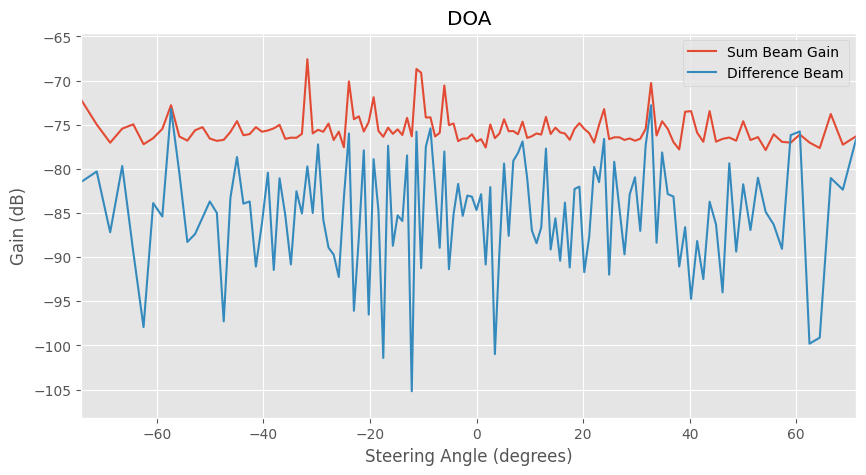


- **Sweep Duration:** 0.84 sec  
- **Max Gain:** -67.58 dB  
- **Max Δ Value:** -72.79  



Exiting Loop


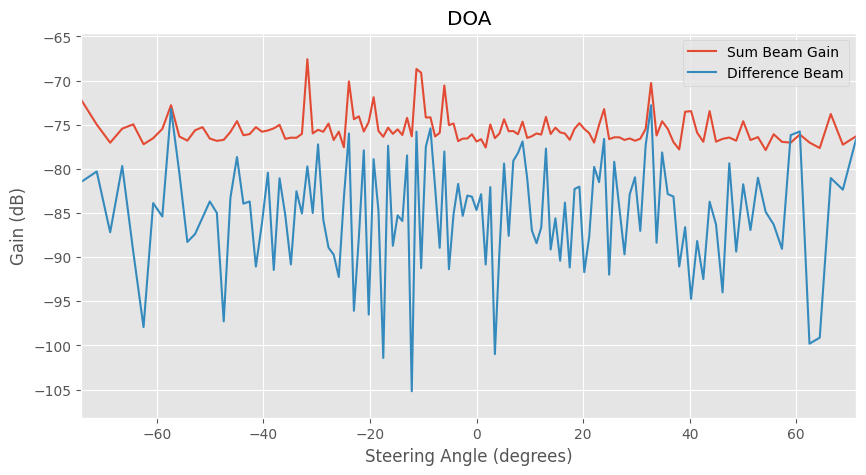

In [7]:
from IPython.display import display, clear_output, Markdown
import matplotlib.pyplot as plt
import numpy as np
import time

# Create 1x1 subplot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plot_display = display("", display_id=True)
status_display = display("", display_id=True)

# Initialize plot lines
sum_line, = ax.plot([], [], label="Sum Beam Gain")
diff_line, = ax.plot([], [], label="Difference Beam")

ax.set_xlabel("Steering Angle (degrees)")
ax.set_ylabel("Gain (dB)")
ax.set_title("DOA")
ax.grid(True)
ax.legend()

gain_list = [127, 127, 127, 127, 127, 127, 127, 127]
for i, g in enumerate(gain_list):
    my_phaser.set_chan_gain(i, g, apply_cal=True)

try:
    while True:
        start = time.time()

        # Run sweep and extract data
        gain, angle, delta, xf, max_gain, phaseValues = calculate_plot(my_phaser)
        sweep_time = time.time() - start

        # Update plot data
        sum_line.set_data(angle, gain)
        diff_line.set_data(angle, delta)

        ax.set_xlim(min(angle), max(angle))
        ymin = min(min(gain), min(delta))
        ymax = max(max(gain), max(delta))
        ax.set_ylim(ymin - 3, ymax + 3)

        # Display updated plot and diagnostics
        
        status_markdown = f"""
- **Sweep Duration:** {sweep_time:.2f} sec  
- **Max Gain:** {np.max(gain):.2f} dB  
- **Max Δ Value:** {np.max(delta):.2f}  

"""
        status_display.update(Markdown(status_markdown))
        plot_display.update(fig)


except KeyboardInterrupt:
    print("Exiting Loop")

